In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import numpy as np
import xml.etree.ElementTree as ET
import json

In [8]:
tree = ET.parse('projet.argos')
root = tree.getroot()

data = {'walls': [], 'target': {}}

for box in root.findall('.//arena/box'):
    box_id = box.get('id')
    sx, sy = map(float, box.get('size').split(',')[:2])
    body = box.find('body')
    x, y = map(float, body.get('position').split(',')[:2])
    yaw = float(body.get('orientation').split(',')[0])
    
    data['walls'].append({
        'id': box_id, 'x': x, 'y': y, 'sx': sx, 'sy': sy, 'yaw': yaw
    })

light = root.find('.//arena/light')
if light is not None:
    x, y = map(float, light.get('position').split(',')[:2])
    data['target'] = {
        'id': light.get('id'),
        'x': x,
        'y': y,
        'color': light.get('color')
    }

with open('arena.json', 'w') as f:
    json.dump(data, f, indent=4)

In [9]:
df = pd.read_csv("experiment_data.csv", names=["robot_id", "step", "x", "y"])

In [10]:
with open('arena.json', 'r') as f:
    arena = json.load(f)

In [11]:
groups = df.groupby("robot_id")

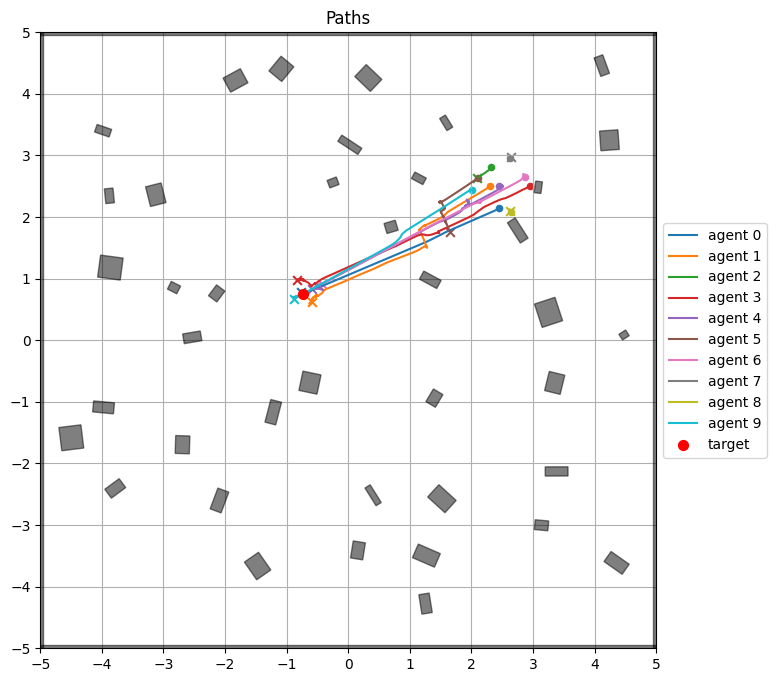

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

for robot_id, group in groups:
    line, = ax.plot(group["x"], group["y"], label=f"agent {robot_id}")
    c = line.get_color()
    ax.scatter(group["x"].iloc[0], group["y"].iloc[0], marker="o", s=20, color=c)
    ax.scatter(group["x"].iloc[-1], group["y"].iloc[-1], marker="x", s=40, color=c)

for w in arena.get('walls', []):
    rect = patches.Rectangle(
        (w['x'] - w['sx'] / 2, w['y'] - w['sy'] / 2),
        w['sx'], w['sy'],
        color='black', alpha=0.5, zorder=2
    )
    t = transforms.Affine2D().rotate_around(w['x'], w['y'], np.radians(w['yaw'])) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)

target = arena.get('target')
if target:
    ax.scatter(target['x'], target['y'], color="red", marker="o", s=50, label="target", zorder=5)

ax.set_title("Paths")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_yticks(np.arange(-5, 6, 1))
ax.grid(True)
ax.set_aspect("equal")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()

In [22]:
target_x = arena['target']['x']
target_y = arena['target']['y']

GOAL_THRESH = 0.50
TICKS_PER_SEC = 10.0

num_agents = len(df['robot_id'].unique())
reached_count = 0
times_to_target = []
total_distance = 0.0

for robot_id, group in df.groupby('robot_id'):
    group = group.sort_values('step')
    
    dist_to_target = np.sqrt((group['x'] - target_x)**2 + (group['y'] - target_y)**2)
    reached_mask = dist_to_target < GOAL_THRESH
    
    if reached_mask.any():
        reached_count += 1
        first_reached_idx = reached_mask.idxmax()
        steps_to_target = group.loc[first_reached_idx, 'step']
        times_to_target.append(steps_to_target)
        
        valid_steps = group[group['step'] <= steps_to_target]
        dist_traveled = np.sqrt(valid_steps['x'].diff()**2 + valid_steps['y'].diff()**2).sum()
        total_distance += dist_traveled
    else:
        dist_traveled = np.sqrt(group['x'].diff()**2 + group['y'].diff()**2).sum()
        total_distance += dist_traveled

mean_time_sec = np.mean(times_to_target) / TICKS_PER_SEC if times_to_target else 0
fastest_time_sec = np.min(times_to_target) / TICKS_PER_SEC if times_to_target else 0
slowest_time_sec = np.max(times_to_target) / TICKS_PER_SEC if times_to_target else 0

print(f"Number of agents: {num_agents}")
print(f"Successfully reached target: {reached_count}")
print(f"Mean time to target: {mean_time_sec:.2f} s")
print(f"Fastest time to target: {fastest_time_sec:.2f} s")
print(f"Slowest time to target: {slowest_time_sec:.2f} s")
print(f"Total traveled distance: {total_distance:.2f} m")

Number of agents: 10
Successfully reached target: 6
Mean time to target: 81.45 s
Fastest time to target: 55.10 s
Slowest time to target: 114.70 s
Total traveled distance: 34.45 m


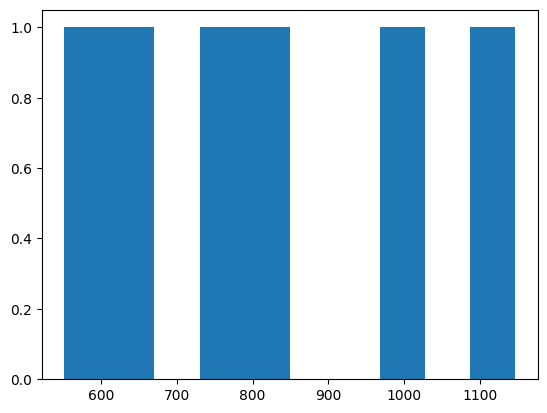

In [24]:
plt.hist(times_to_target)
plt.show()